# Week 1 - Customer Churn EDA
**Author:** Zaryab Malik 
**Date:** September 11, 2026

In [15]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Libraries imported successfully!')

Libraries imported successfully!


In [16]:
# Load data (Kaggle path)
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# First look
print('Dataset shape:', df.shape)
print()
df.head()

Dataset shape: (7043, 21)



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Dataset Overview 

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [18]:
df.describe() 

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [19]:
print('Missing Values:') 
missing = df.isnull().sum() 
print(missing[missing > 0]) 

# Fix TotalCharges 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') 

Missing Values:
Series([], dtype: int64)


In [20]:
print('Churn Distribution:') 
print(df['Churn'].value_counts())
print() 
print('Churn Percentage:') 
print(df['Churn'].value_counts(normalize=True) * 100) 

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


Key Findings: Dataset has X customers. Churn rate is Y%. Z missing values in TotalCharges. Features include demographics, services, and account info. 

 ## 2. Numerical Features Analysis 

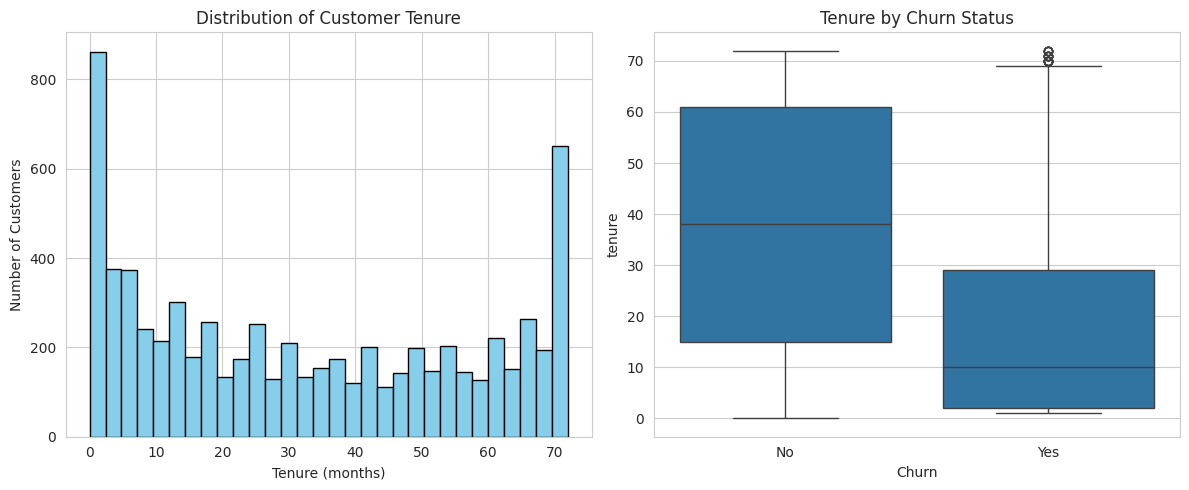

In [21]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['tenure'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Tenure')

plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure by Churn Status')
plt.tight_layout()
plt.show()

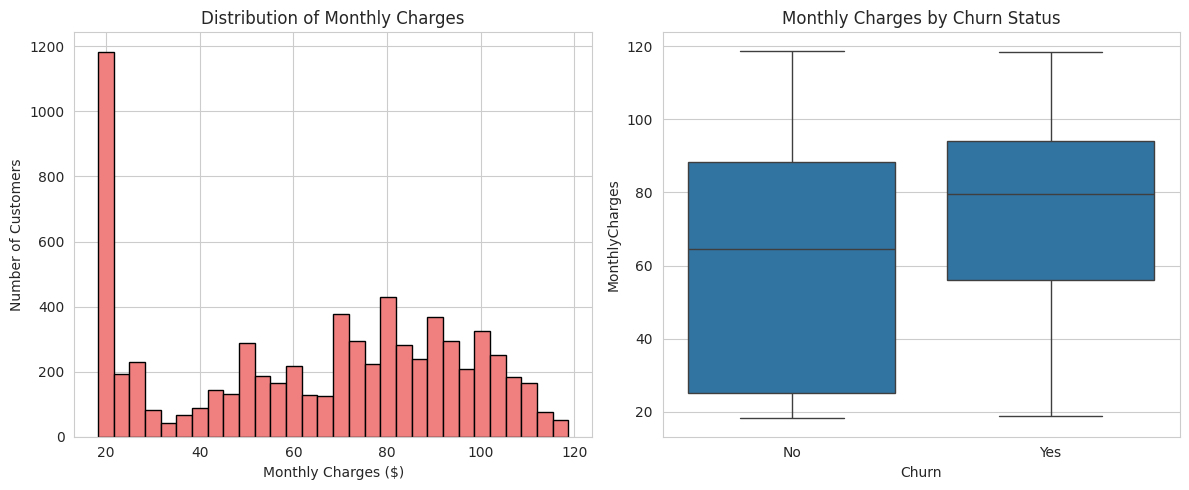

In [22]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) 
plt.hist(df['MonthlyCharges'], bins=30, color='lightcoral', edgecolor='black') 
plt.xlabel('Monthly Charges ($)') 
plt.ylabel('Number of Customers') 
plt.title('Distribution of Monthly Charges')

plt.subplot(1, 2, 2) 
sns.boxplot(x='Churn', y='MonthlyCharges', data=df) 
plt.title('Monthly Charges by Churn Status') 
plt.tight_layout()
plt.show() 

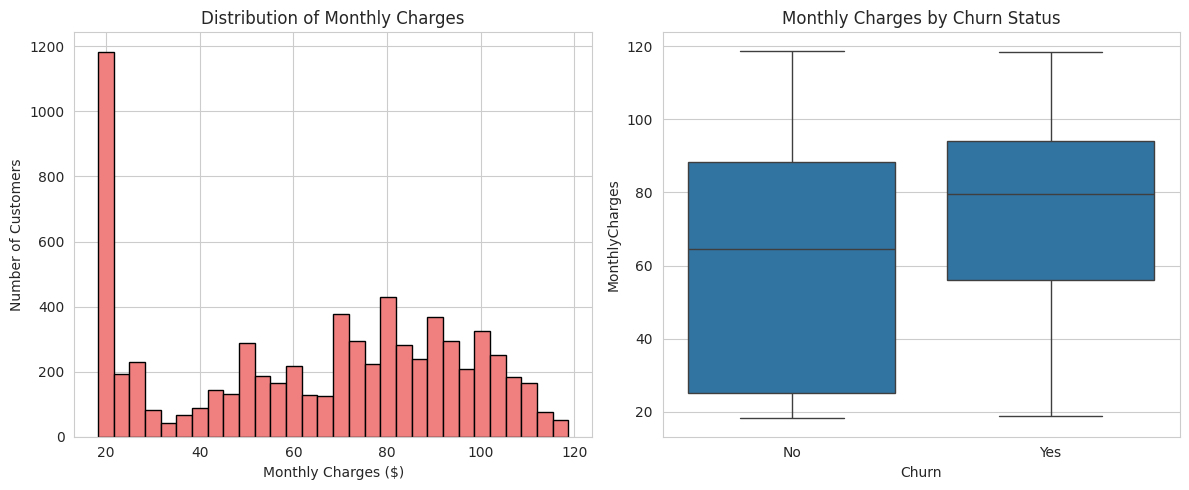

In [23]:
# Visualization 2: Monthly Charges
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['MonthlyCharges'], bins=30, color='lightcoral', edgecolor='black')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Monthly Charges')

plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Churn Status')

plt.tight_layout()
plt.show()

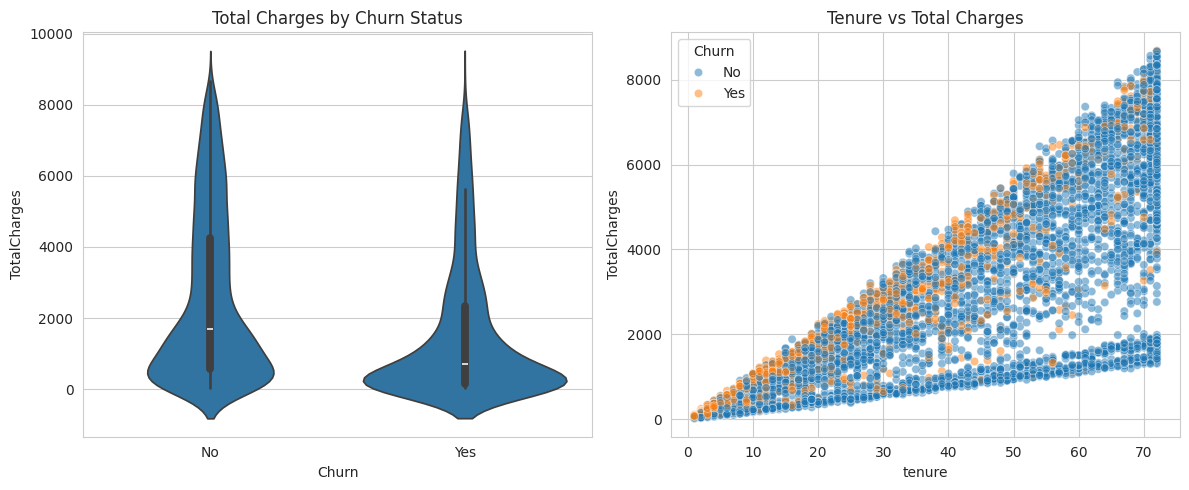

In [24]:
# Convert TotalCharges to numeric (handling empty strings as NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df_clean = df[df['TotalCharges'].notna()]

# Visualization 3: Total Charges Analysis
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.violinplot(x='Churn', y='TotalCharges', data=df_clean)
plt.title('Total Charges by Churn Status')

plt.subplot(1, 2, 2)
sns.scatterplot(x='tenure', y='TotalCharges', hue='Churn', data=df_clean, alpha=0.5)
plt.title('Tenure vs Total Charges')

plt.tight_layout()
plt.show()

 ## 3. Categorical Features Analysis 

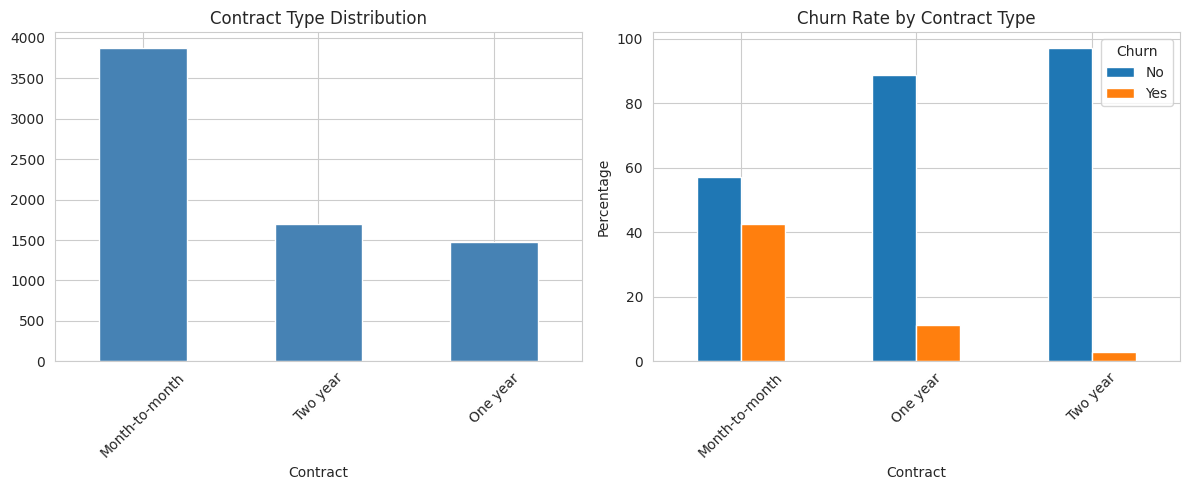

In [25]:
plt.figure(figsize=(12, 5))

# Subplot 1: Contract Type Distribution
plt.subplot(1, 2, 1)
df['Contract'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Contract Type Distribution')
plt.xticks(rotation=45)

# Subplot 2: Churn Rate by Contract Type
plt.subplot(1, 2, 2)
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=False, ax=plt.gca())
plt.title('Churn Rate by Contract Type')
plt.ylabel('Percentage')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

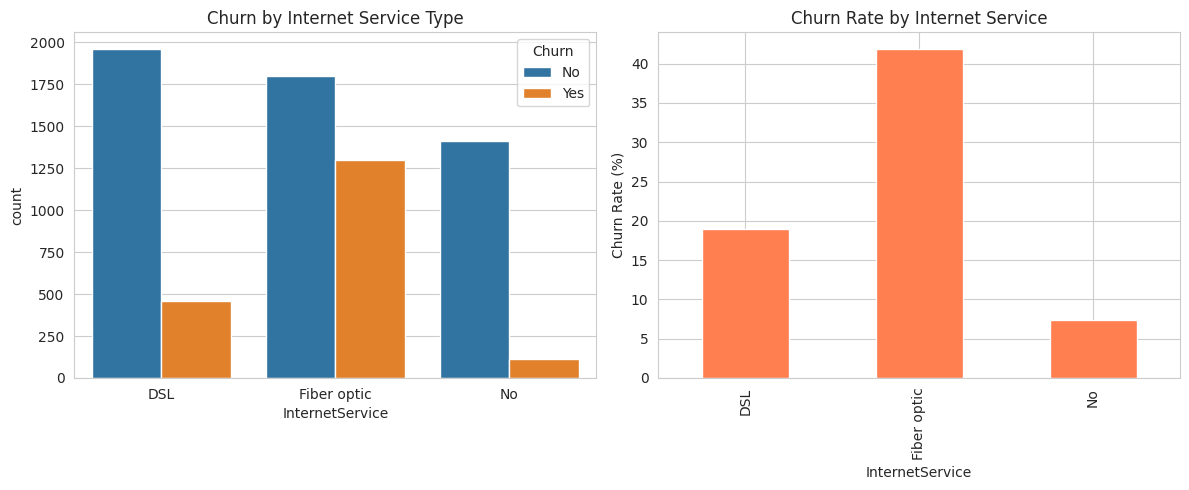

In [26]:
plt.figure(figsize=(12, 5))

# Subplot 1: Churn by Internet Service Type
plt.subplot(1, 2, 1)
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn by Internet Service Type')

# Subplot 2: Churn Rate by Internet Service
plt.subplot(1, 2, 2)
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
internet_churn['Yes'].plot(kind='bar', color='coral')
plt.title('Churn Rate by Internet Service')
plt.ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

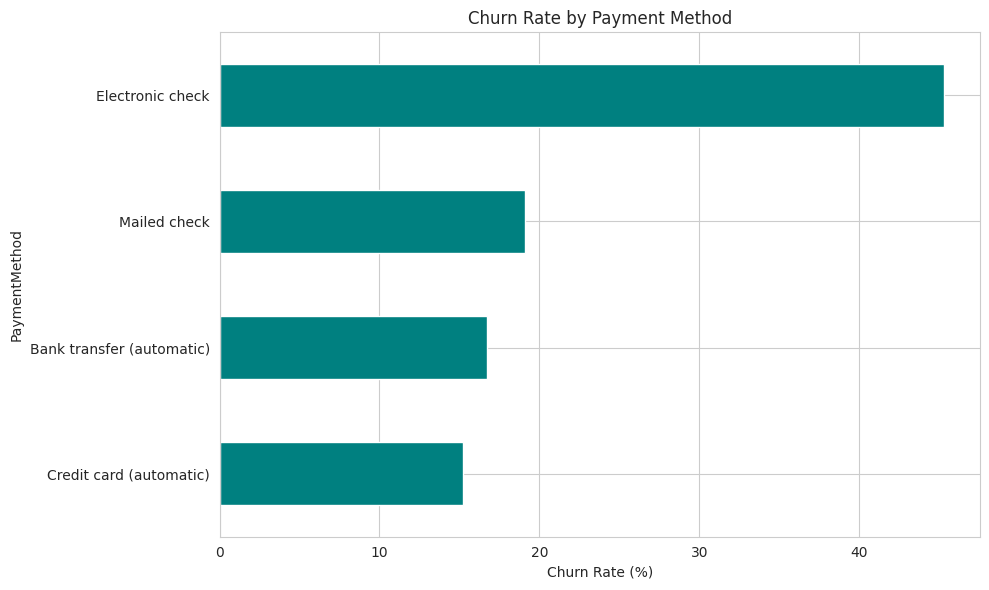

In [27]:
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

plt.figure(figsize=(10, 6))
payment_churn['Yes'].sort_values().plot(kind='barh', color='teal')
plt.title('Churn Rate by Payment Method')
plt.xlabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

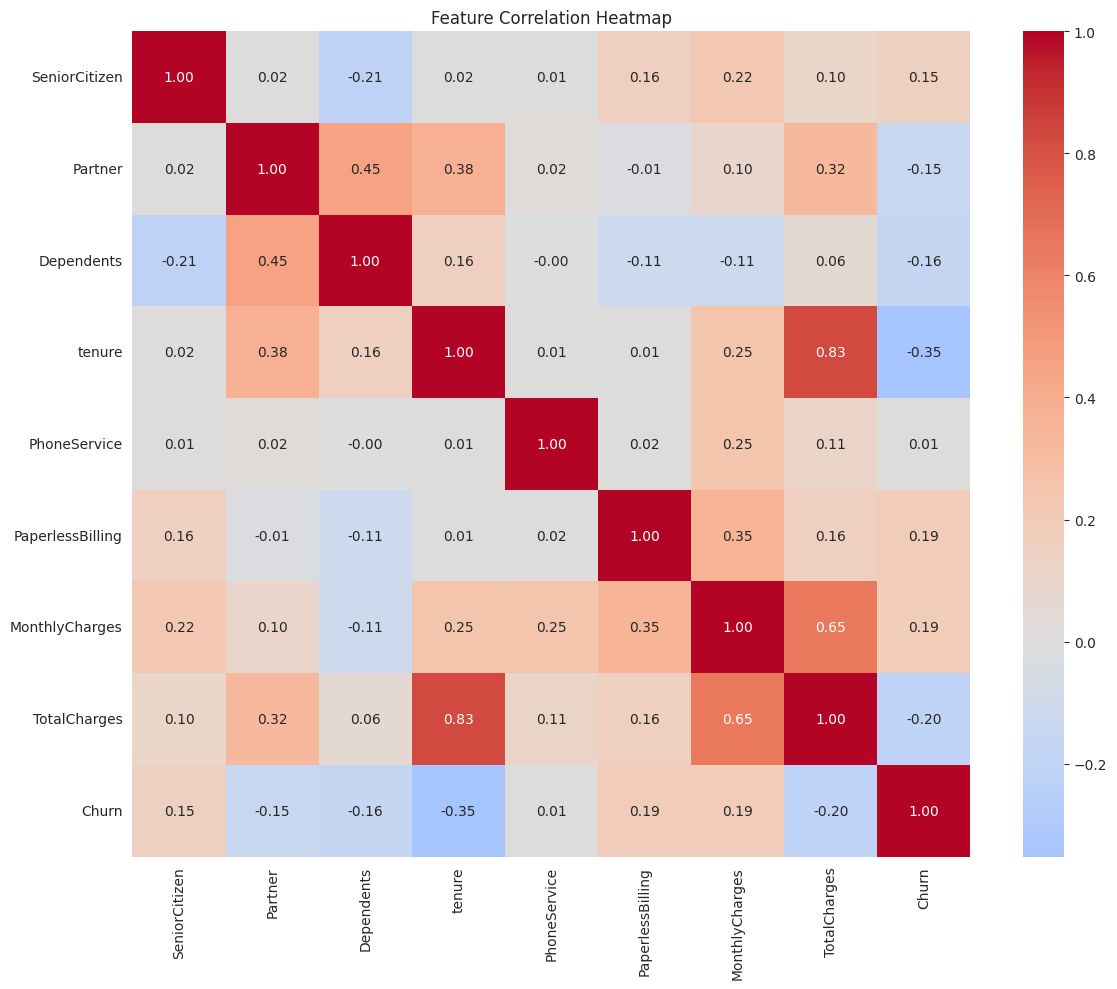

In [28]:
# Prepare numeric data
df_numeric = df.copy()
binary_cols = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in binary_cols:
    if col in df_numeric.columns:
        df_numeric[col] = df_numeric[col].map({'Yes': 1, 'No': 0})

numeric_features = df_numeric.select_dtypes(include=[np.number])

# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_features.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

Include: High-risk customer characteristics (contract type, tenure, charges, services, payment method). Patterns you observed. Questions for next week. 

## 3. Summary of Insights & Documentation

### High-Risk Customer Profile
* **Contract Type:** Month-to-month contracts exhibit significantly higher churn compared to 1-year or 2-year commitments.
* **Tenure:** Customers with short tenure (0–12 months) are at the highest risk of churning.
* **Monthly Charges:** Higher monthly charges strongly correlate with increased churn rates.
* **Services:** Fiber optic internet subscribers experience noticeably higher churn than DSL or non-internet users.
* **Payment Method:** Electronic check users demonstrate the highest churn rate among all payment methods.

### Observed Key Patterns
1. Short tenure combined with month-to-month contracts represents the primary indicator of immediate customer loss.
2. High monthly charges drive churn unless anchored by long-term contract discounts or bundle retention offers.
3. Fiber optic customers churn at a higher rate despite paying more, pointing to potential service quality or pricing issues.

### Questions for Next Week
* How do add-on security/support services impact churn among month-to-month users?
* Can predictive machine learning models accurately forecast churn probability for newly onboarded customers?